In [6]:
from langgraph.graph import START, END, StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from my_project.rag.core.schemas import WebSearch, Escalation, PersonaClassification, ChatbotState, Retrieval
from my_project.rag.core.prompts import persona_prompt, escalation_prompt, retrieval_prompt, general_answer_prompt,answer_prompt
from my_project.rag.core.config import settings
from my_project.rag.load_retrieve.retriever import get_retriever
from dotenv import load_dotenv
load_dotenv()

model1 = ChatGoogleGenerativeAI(model = settings.GOOGLE_MODEL_LITE)
model2 = ChatGoogleGenerativeAI(model = settings.GOOGLE_MODEL_HEAVY)
hf_llm = HuggingFaceEndpoint(repo_id=settings.HF_LLM)
model3 = ChatHuggingFace(llm = hf_llm)
parser = StrOutputParser()
retriever = get_retriever()
websearch_decider = model1.with_structured_output(WebSearch)
escalation_decider = model1.with_structured_output(Escalation)
persona_detector = model1.with_structured_output(PersonaClassification)
retrieval_decider = model1.with_structured_output(Retrieval)

In [7]:
# Nodes/Functions
def PersonaDetection(state : ChatbotState):
    chain = persona_prompt | persona_detector
    persona = chain.invoke({'query':state.query})
    return {'persona_classification' : persona}

def EscalationDecision(state : ChatbotState):
    chain = escalation_prompt | escalation_decider
    result = chain.invoke({
        'persona' : state.persona_classification.persona,
        'query' : state.query,
        'chat_history' : state.chat_history[-4:] if state.chat_history else []
    })
    return {'escalate':result.escalate}

def EscalationRouter(state : ChatbotState):
    if state.escalate:
        return "HumanSupport"
    else:
        return "RetrievalDecider"
    
def HumanSupport(state: ChatbotState):
    return {"answer": "Your issue has been escalated to a human support agent."}

def RetrievalDecider(state : ChatbotState):
    chain = retrieval_prompt | retrieval_decider
    result = chain.invoke({
        'query':state.query,
        'chat_history':state.chat_history[-2:] if state.chat_history else []
        })
    return {'retrieval':result.retrieval}

def RetrievalRouter(state : ChatbotState):
    if state.retrieval:
        return "Retrieve"
    else:
        return "GeneralAnswer"
    
def Retrieve(state : ChatbotState):
    docs = retriever.invoke(state.query)
    return {'docs':docs}

def GeneralAnswer(state : ChatbotState):
    chain = general_answer_prompt | model1
    result = chain.invoke({
        'persona' : state.persona_classification.persona,
        'query' : state.query,
        'chat_history' : state.chat_history[-2:] if state.chat_history else []
    })
    return {'answer':result.content,'chat_history':[result]}

def Answer(state : ChatbotState):
    chain = answer_prompt | model2
    context = "\n\n".join(doc.page_content for doc in state.docs)
    result = chain.invoke({
        'context' : context,
        'persona' : state.persona_classification.persona,
        'query' : state.query,
        'chat_history' : state.chat_history[-4:] if state.chat_history else []
    }) 
    return {'answer':result.content,'chat_history':[result]}

In [8]:
graph = StateGraph(ChatbotState)

graph.add_node("PersonaDetection",PersonaDetection)
graph.add_node("EscalationDecision",EscalationDecision)
graph.add_node("HumanSupport",HumanSupport)
graph.add_node("RetrievalDecider",RetrievalDecider)
graph.add_node("Retrieve",Retrieve)
graph.add_node("GeneralAnswer",GeneralAnswer)
graph.add_node("Answer",Answer)


graph.add_edge(START,"PersonaDetection")
graph.add_edge("PersonaDetection","EscalationDecision")
graph.add_conditional_edges("EscalationDecision",EscalationRouter)
graph.add_edge("EscalationDecision","HumanSupport")
graph.add_edge("EscalationDecision","RetrievalDecider")
graph.add_edge("HumanSupport",END)
graph.add_conditional_edges("RetrievalDecider",RetrievalRouter)
graph.add_edge("RetrievalDecider","Retrieve")
graph.add_edge("RetrievalDecider","GeneralAnswer")
graph.add_edge("GeneralAnswer",END)
graph.add_edge("Retrieve","Answer")
graph.add_edge("Answer",END)

chatbot = graph.compile()

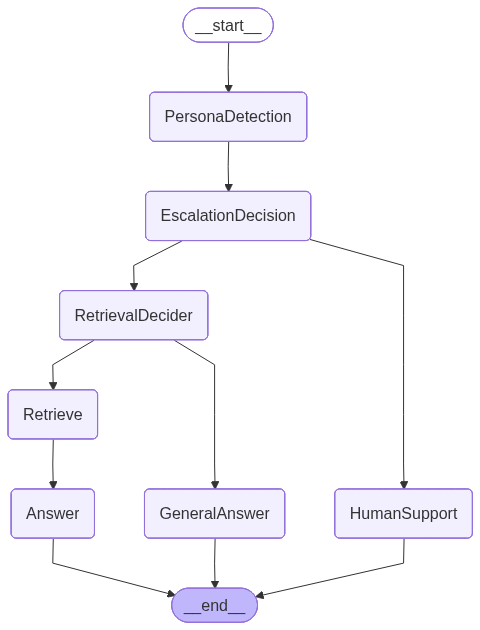

In [9]:
chatbot

In [10]:
initial_state = {'query':'What are the available coupons'}
final_state = chatbot.invoke(initial_state)

In [11]:
final_state

{'query': 'What are the available coupons',
 'escalate': False,
 'retrieval': True,
 'persona_classification': PersonaClassification(persona='business_executive', score=0.8),
 'answer': "Our knowledge base outlines the general terms and conditions for offers and coupons rather than a real-time list of currently available promotions.\n\nHere's what the policy states regarding coupons and offers:\n*   **Availability:** Swiggy may run marketing and promotional campaigns periodically, providing various offers and promotional offers to be used on the Platforms.\n*   **Exclusions:** Offers may not be valid when combined with other promotions, discounts, or vouchers. Certain restaurants may also be excluded from offers without prior notice.\n*   **Usage:** Unless otherwise stated, offers can only be used on our Platforms and are not exchangeable for cash or valid on take-away/delivery unless specified.\n*   **Specifics:** Details for offers like movie codes or cashback coupons are typically e

In [14]:
print(final_state['answer'])

Our knowledge base outlines the general terms and conditions for offers and coupons rather than a real-time list of currently available promotions.

Here's what the policy states regarding coupons and offers:
*   **Availability:** Swiggy may run marketing and promotional campaigns periodically, providing various offers and promotional offers to be used on the Platforms.
*   **Exclusions:** Offers may not be valid when combined with other promotions, discounts, or vouchers. Certain restaurants may also be excluded from offers without prior notice.
*   **Usage:** Unless otherwise stated, offers can only be used on our Platforms and are not exchangeable for cash or valid on take-away/delivery unless specified.
*   **Specifics:** Details for offers like movie codes or cashback coupons are typically emailed or specified with the offer itself.

To find specific available coupons, you would typically need to check the Swiggy platform directly, as these offers are dynamic and may change freque